# پروژه نهایی درس تحلیل داده

## تحلیل داده‌های رزرو هتل (Hotel Booking)

### مراحل پروژه

- خواندن دیتاست
- بررسی اولیه
- پاکسازی داده‌ها
- کاهش حجم حافظه
- تحلیل داده‌ها
- رسم نمودار
- نتیجه‌گیری

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
import os

os.makedirs("images",exist_ok=True)

In [5]:
plt.style.use("ggplot")

sns.set_style("whitegrid")

In [8]:
df=pd.read_csv(r"Hotel Booking.csv.txt")

In [9]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [10]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [11]:
df.shape

(119390, 32)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [13]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [14]:
df.describe(include="all")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,...,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,...,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,...,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,...,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,...,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,...,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,...,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,...,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,...,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [15]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [16]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

## بررسی داده‌های گمشده

In [17]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

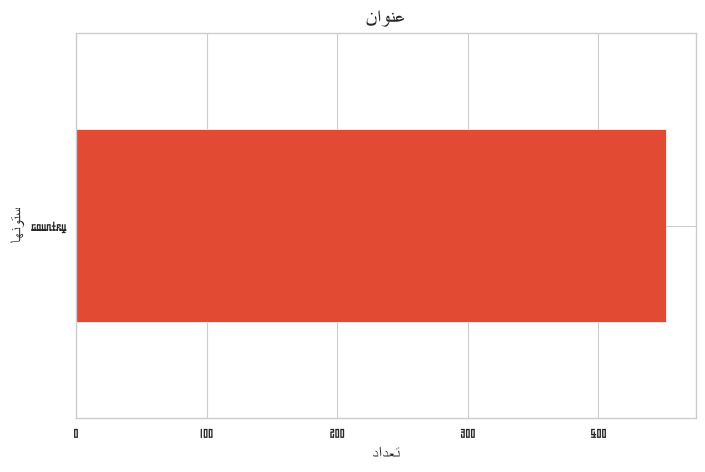

In [40]:
missing=df.isnull().sum()

missing=missing[missing>0]

missing.sort_values().plot(
kind="barh",
figsize=(8,5)
)

plt.title("عنوان")


plt.xlabel("تعداد")

plt.ylabel("ستونها")

plt.savefig("images/missing_values.png",
dpi=300,
bbox_inches="tight")

plt.show()

In [23]:
df=df.drop(columns=["company"])

df["agent"]=df["agent"].fillna(0)

df["children"]=df["children"].fillna(
df["children"].median()
)

In [24]:
print("Missing Values")

df.isnull().sum()

Missing Values


hotel                               0
is_canceled                         0
lead_time                           0
arrival_date_year                   0
arrival_date_month                  0
arrival_date_week_number            0
arrival_date_day_of_month           0
stays_in_weekend_nights             0
stays_in_week_nights                0
adults                              0
children                            0
babies                              0
meal                                0
country                           488
market_segment                      0
distribution_channel                0
is_repeated_guest                   0
previous_cancellations              0
previous_bookings_not_canceled      0
reserved_room_type                  0
assigned_room_type                  0
booking_changes                     0
deposit_type                        0
agent                               0
days_in_waiting_list                0
customer_type                       0
adr         

## حذف داده‌های تکراری

In [25]:
print("Before")

print(df.shape)

df=df.drop_duplicates()

print("After")

print(df.shape)

Before
(119390, 31)
After
(87389, 31)


In [26]:
df.duplicated().sum()

0

## کاهش حجم دیتاست

In [27]:
before=df.memory_usage(
deep=True
).sum()/1024**2

print(before)

27.842159271240234


In [28]:
category_columns=[

"hotel",

"meal",

"market_segment",

"distribution_channel",

"reserved_room_type",

"assigned_room_type",

"deposit_type",

"customer_type",

"reservation_status"

]

In [29]:
for col in category_columns:

    df[col]=df[col].astype("category")

In [30]:
after=df.memory_usage(
deep=True
).sum()/1024**2

print(after)

17.686351776123047


In [31]:
print("Before :",before)

print("After :",after)

print("Reduced :",before-after)

Before : 27.842159271240234
After : 17.686351776123047
Reduced : 10.155807495117188


In [32]:
memory=df.memory_usage(
deep=True
)

memory.sort_values(
ascending=False
).head(10)

reservation_status_date           1583926
arrival_date_month                1222379
country                            969754
total_of_special_requests          699112
required_car_parking_spaces        699112
adr                                699112
days_in_waiting_list               699112
agent                              699112
booking_changes                    699112
previous_bookings_not_canceled     699112
dtype: int64

# تحلیل داده ها (EDA)

در این بخش ویژگی‌های مختلف دیتاست با استفاده از نمودار بررسی می‌شوند.

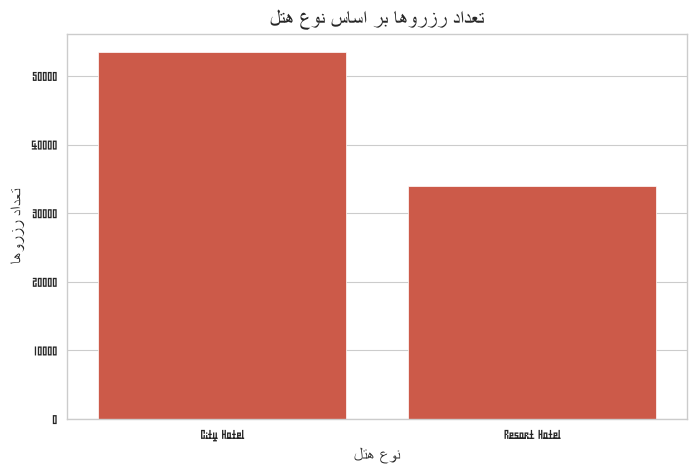

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel"
)

plt.title("تعداد رزروها بر اساس نوع هتل")

plt.xlabel("نوع هتل")

plt.ylabel("تعداد رزروها")

plt.savefig("images/hotel_count.png",dpi=300,bbox_inches="tight")

plt.show()

بیشتر رزروها مربوط به City Hotel است، بنابراین مشتریان بیشتر هتل‌های شهری را انتخاب کرده‌اند.

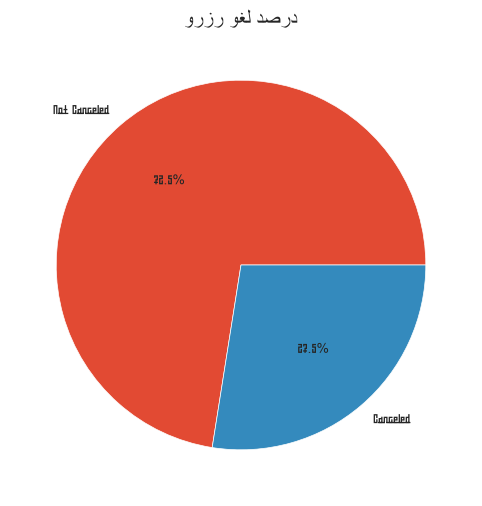

In [42]:
plt.figure(figsize=(6,6))

df["is_canceled"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Not Canceled","Canceled"]
)

plt.ylabel("")

plt.title("درصد لغو رزرو")

plt.savefig("images/cancel.png",dpi=300,bbox_inches="tight")

plt.show()

درصد قابل توجهی از رزروها لغو شده‌اند؛ بنابراین بررسی علت لغو رزرو اهمیت دارد

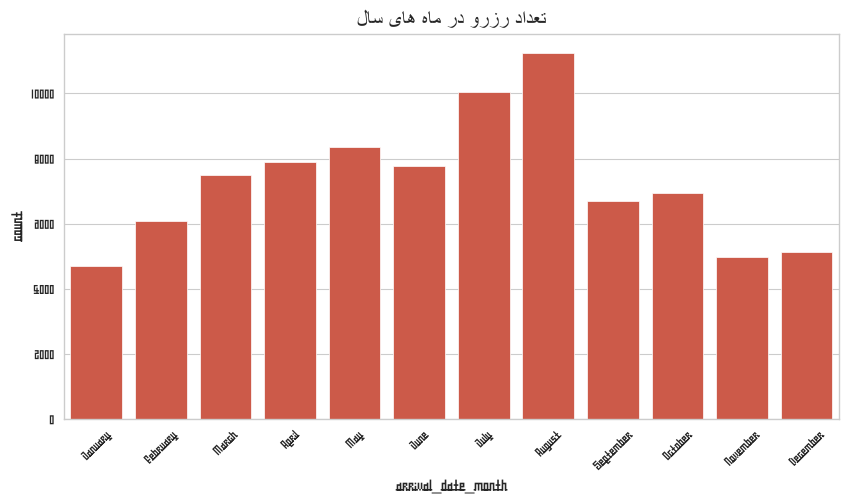

In [38]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="arrival_date_month",
    order=[
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ]
)

plt.xticks(rotation=45)

plt.title("تعداد رزرو در ماه های سال")

plt.savefig("images/month.png",dpi=300,bbox_inches="tight")

plt.show()

در برخی ماه‌ها تعداد رزروها بیشتر است که نشان‌دهنده فصل‌های پرتقاضا در صنعت هتل‌داری است

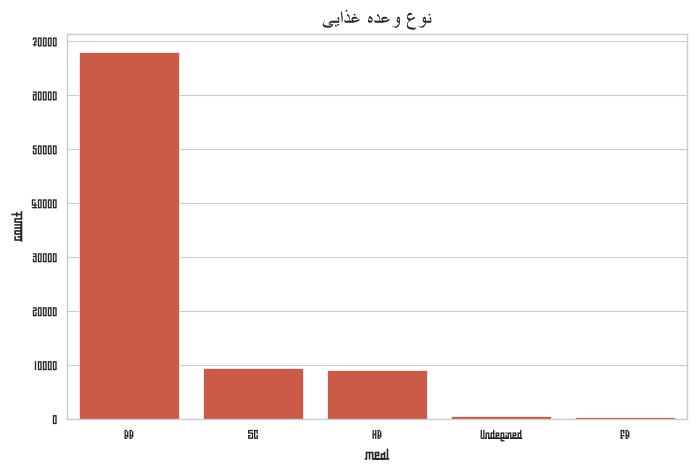

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="meal",
    order=df["meal"].value_counts().index
)

plt.title("نوع وعده غذایی")

plt.savefig("images/meal.png",dpi=300,bbox_inches="tight")

plt.show()

بیشترین رزروها مربوط به وعده غذایی BB است

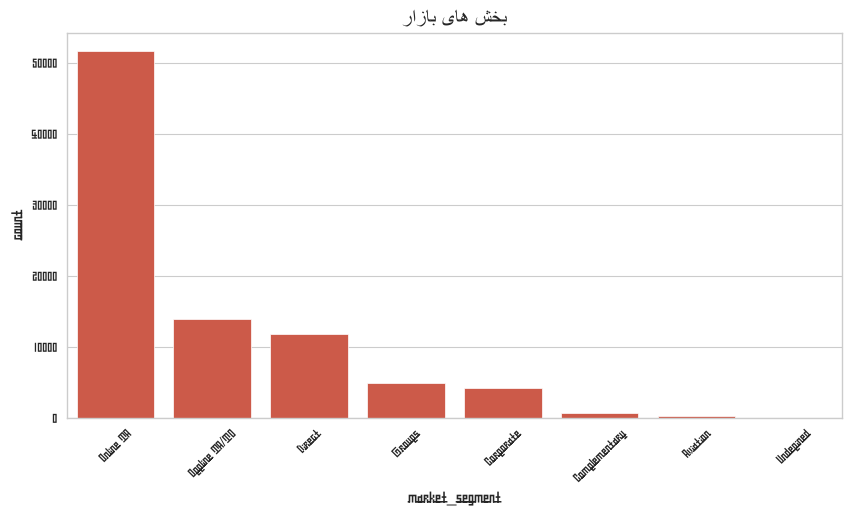

In [43]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="market_segment",
    order=df["market_segment"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("بخش های بازار")

plt.savefig("images/market_segment.png",dpi=300,bbox_inches="tight")

plt.show()

بیشتر مشتریان از طریق Online TA رزرو انجام داده‌اند

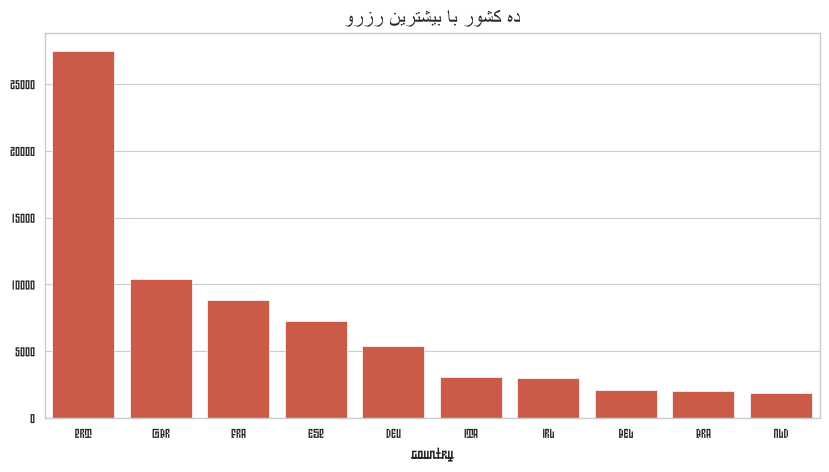

In [45]:
plt.figure(figsize=(10,5))

top_country=df["country"].value_counts().head(10)

sns.barplot(
    x=top_country.index,
    y=top_country.values
)

plt.title("ده کشور با بیشترین رزرو")

plt.savefig("images/country.png",dpi=300,bbox_inches="tight")

plt.show()

بیشترین مشتریان از چند کشور مشخص هستند و می‌توان تبلیغات را روی همین کشورها متمرکز کرد

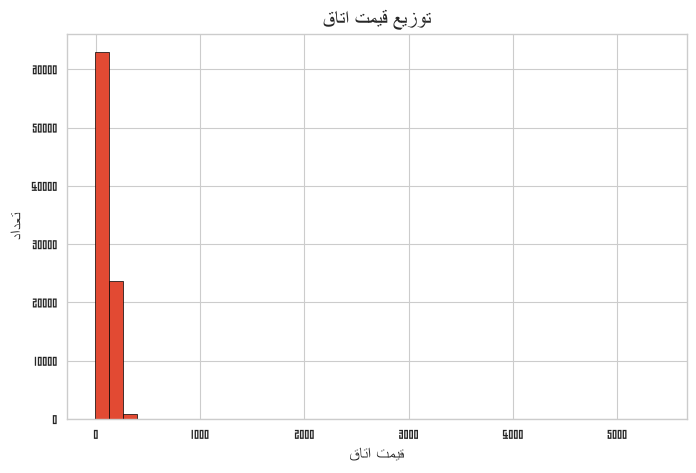

In [46]:
plt.figure(figsize=(8,5))

plt.hist(
    df["adr"],
    bins=40,
    edgecolor="black"
)

plt.title("توزیع قیمت اتاق")

plt.xlabel("قیمت اتاق")

plt.ylabel("تعداد")

plt.savefig("images/adr_hist.png",dpi=300,bbox_inches="tight")

plt.show()

اکثر قیمت‌ها در یک بازه مشخص قرار دارند و تعداد کمی قیمت بسیار بالا دارند

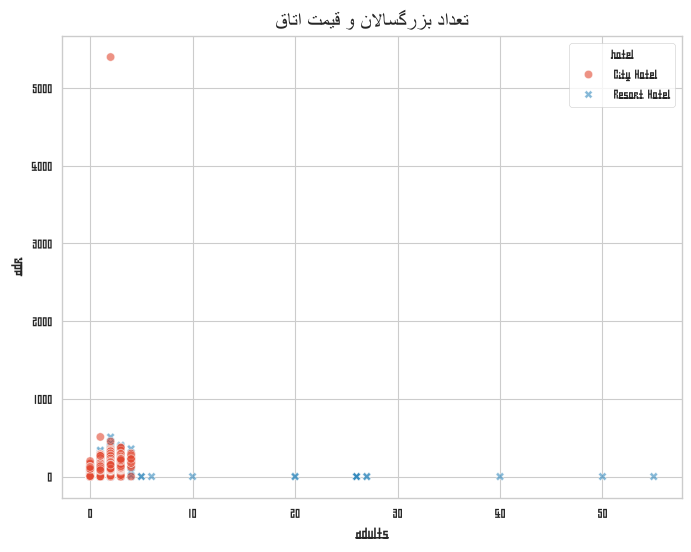

In [49]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="adults",
    y="adr",
    hue="hotel",
    style="hotel",
    alpha=0.6
)

plt.title("تعداد بزرگسالان و قیمت اتاق")

plt.savefig("images/adults_adr.png",dpi=300,bbox_inches="tight")

plt.show()

بیشتر رزروها برای دو بزرگسال انجام شده است و بین دو نوع هتل اختلاف قیمت مشاهده می‌شود

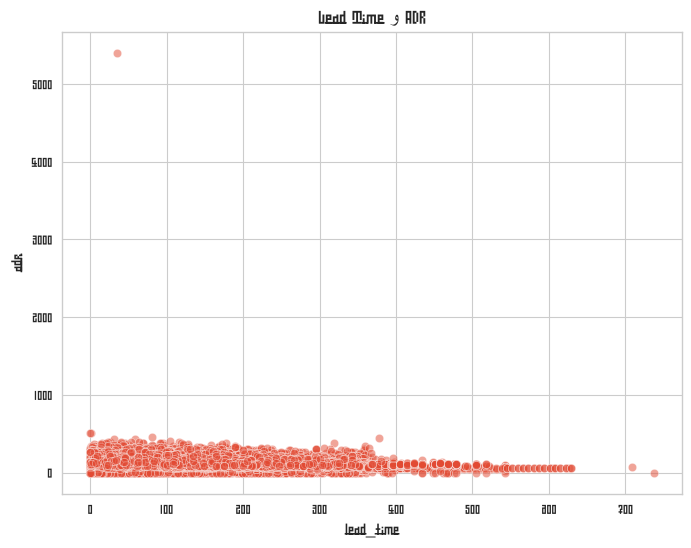

In [50]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    alpha=0.5
)

plt.title("Lead Time و ADR")

plt.savefig("images/lead_adr.png",dpi=300,bbox_inches="tight")

plt.show()

پراکندگی نقاط نشان می‌دهد رابطه خطی قوی بین Lead Time و ADR وجود ندارد

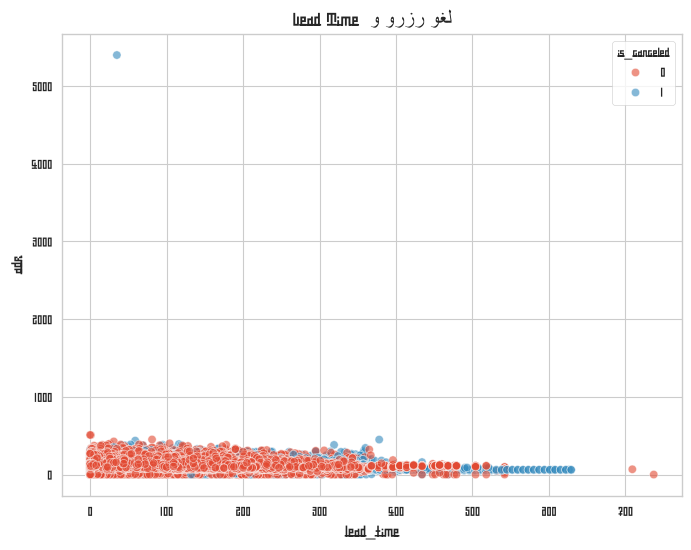

In [52]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    hue="is_canceled",
    alpha=0.6
)

plt.title("Lead Time  لغو رزرو و")

plt.savefig("images/lead_cancel.png",dpi=300,bbox_inches="tight")

plt.show()

بخشی از رزروهایی که فاصله زمانی بیشتری تا تاریخ ورود داشته‌اند، لغو شده‌اند

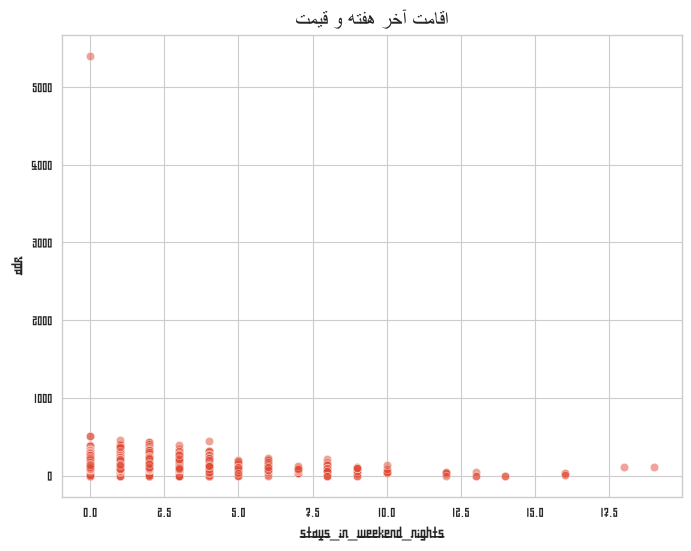

In [53]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="stays_in_weekend_nights",
    y="adr",
    alpha=0.5
)

plt.title("اقامت آخر هفته و قیمت")

plt.savefig("images/weekend.png",dpi=300,bbox_inches="tight")

plt.show()

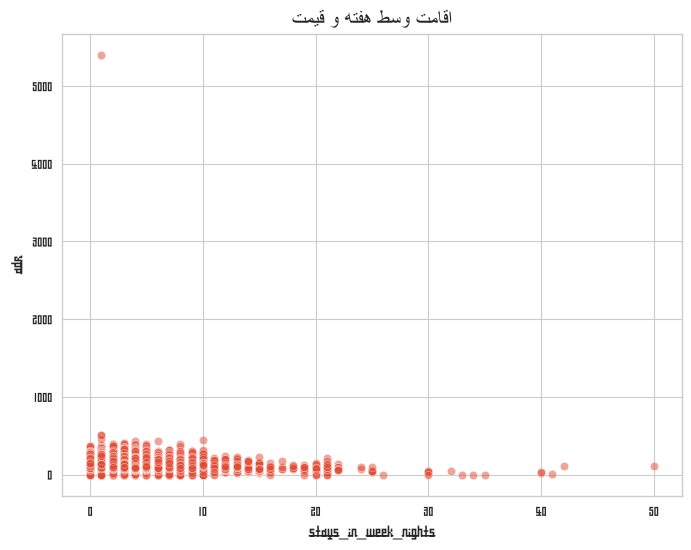

In [54]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="stays_in_week_nights",
    y="adr",
    alpha=0.5
)

plt.title("اقامت وسط هفته و قیمت")

plt.savefig("images/week.png",dpi=300,bbox_inches="tight")

plt.show()

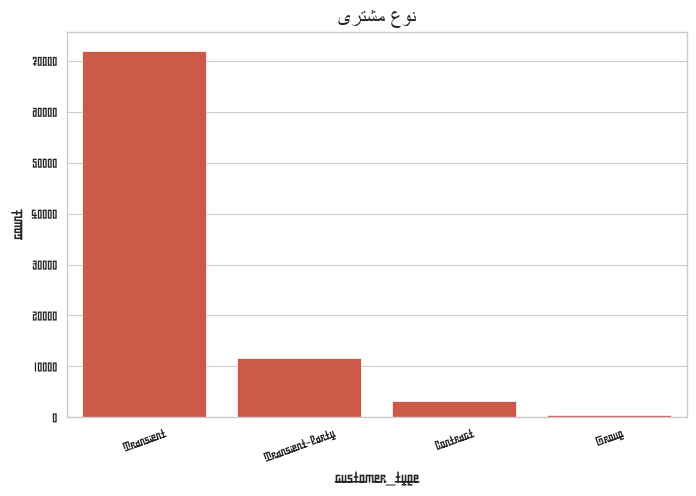

In [55]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_type",
    order=df["customer_type"].value_counts().index
)

plt.xticks(rotation=20)

plt.title("نوع مشتری")

plt.savefig("images/customer.png",dpi=300,bbox_inches="tight")

plt.show()

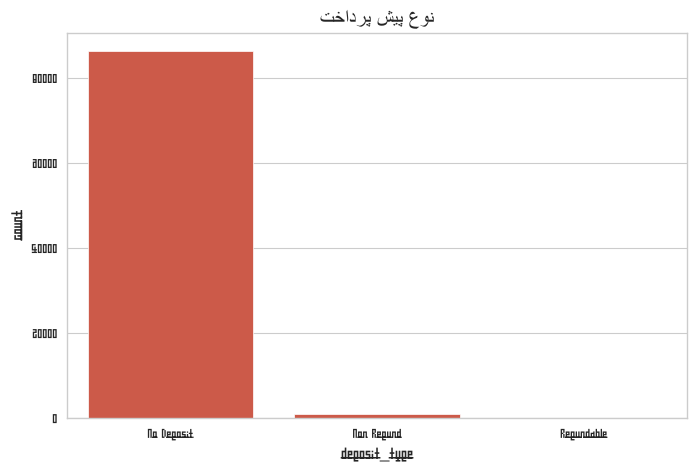

In [56]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="deposit_type",
    order=df["deposit_type"].value_counts().index
)

plt.title("نوع پیش پرداخت")

plt.savefig("images/deposit.png",dpi=300,bbox_inches="tight")

plt.show()

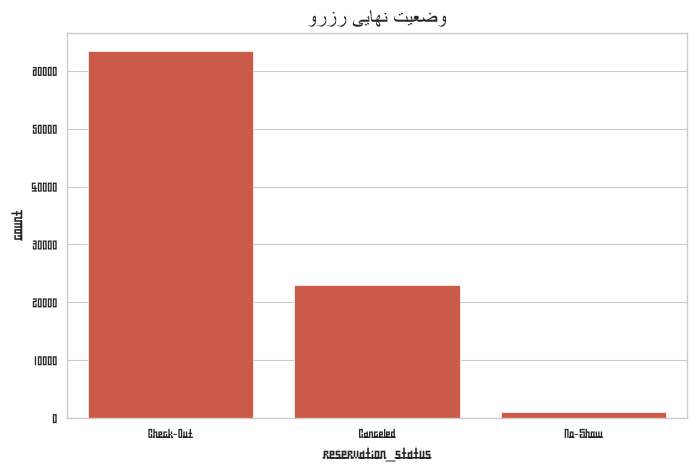

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="reservation_status",
    order=df["reservation_status"].value_counts().index
)

plt.title("وضعیت نهایی رزرو")

plt.savefig("images/status.png",dpi=300,bbox_inches="tight")

plt.show()

In [58]:
df["country"].value_counts().head(10)

country
PRT    27449
GBR    10432
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

In [59]:
df["market_segment"].value_counts()

market_segment
Online TA        51615
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4208
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

In [60]:
df["customer_type"].value_counts()

customer_type
Transient          71982
Transient-Party    11724
Contract            3139
Group                544
Name: count, dtype: int64

## نتیجه بخش دوم

در این بخش با استفاده از نمودارهای مختلف، توزیع داده‌ها و ارتباط بین برخی متغیرها بررسی شد. مشاهده شد که City Hotel بیشترین رزرو را دارد، بخش زیادی از رزروها از طریق Online TA انجام شده‌اند و بخشی از رزروها نیز لغو شده‌اند

# بررسی روابط بین متغیرها
در این قسمت با استفاده از نمودارهای BoxPlot و Heatmap ارتباط بین متغیرهای مختلف بررسی می‌شود

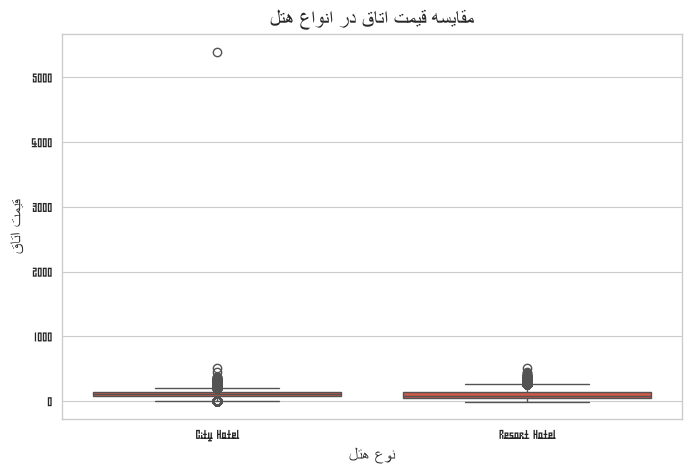

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="hotel",
    y="adr"
)

plt.title("مقایسه قیمت اتاق در انواع هتل")

plt.xlabel("نوع هتل")

plt.ylabel("قیمت اتاق")

plt.savefig("images/box_hotel_adr.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

قیمت اتاق در City Hotel و Resort Hotel متفاوت است و هر دو دارای داده‌های پرت هستند

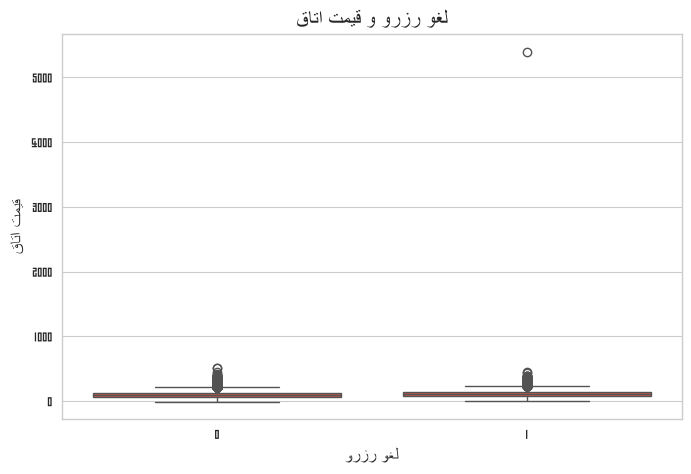

In [63]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="is_canceled",
    y="adr"
)

plt.title("لغو رزرو و قیمت اتاق")

plt.xlabel("لغو رزرو")

plt.ylabel("قیمت اتاق")

plt.savefig("images/box_cancel_adr.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

بین قیمت اتاق و لغو رزرو اختلاف مشاهده می‌شود

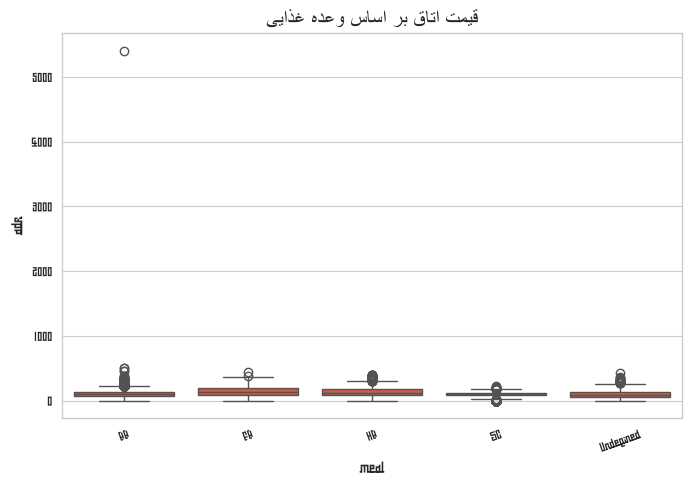

In [64]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="meal",
    y="adr"
)

plt.xticks(rotation=20)

plt.title("قیمت اتاق بر اساس وعده غذایی")

plt.savefig("images/box_meal.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

نوع وعده غذایی انتخاب شده بر قیمت نهایی رزرو تأثیر دارد

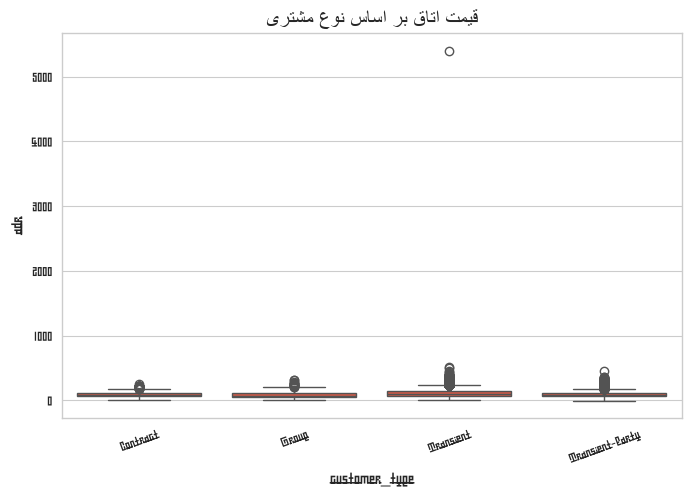

In [65]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="customer_type",
    y="adr"
)

plt.xticks(rotation=20)

plt.title("قیمت اتاق بر اساس نوع مشتری")

plt.savefig("images/customer_box.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

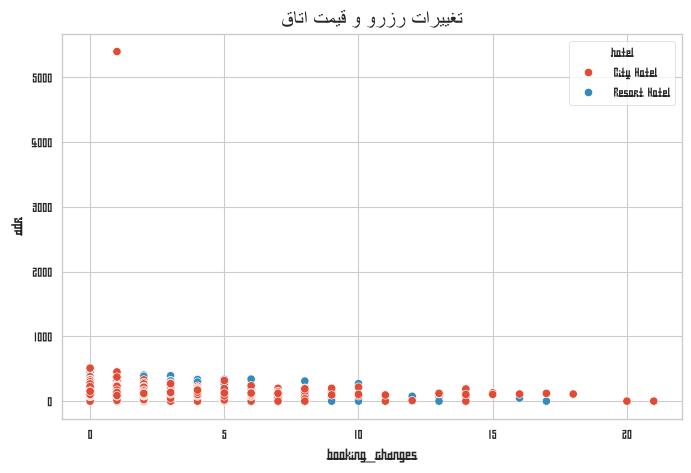

In [66]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="booking_changes",
    y="adr",
    hue="hotel"
)

plt.title("تغییرات رزرو و قیمت اتاق")

plt.savefig("images/booking_change.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

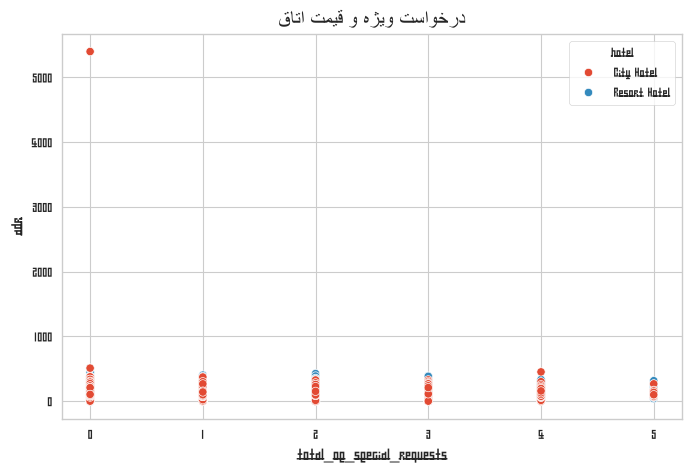

In [67]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="total_of_special_requests",
    y="adr",
    hue="hotel"
)

plt.title("درخواست ویژه و قیمت اتاق")

plt.savefig("images/request.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

بیشتر مشتریان درخواست ویژه کمی داشته‌اند

In [68]:
corr=df.select_dtypes(include=np.number).corr()

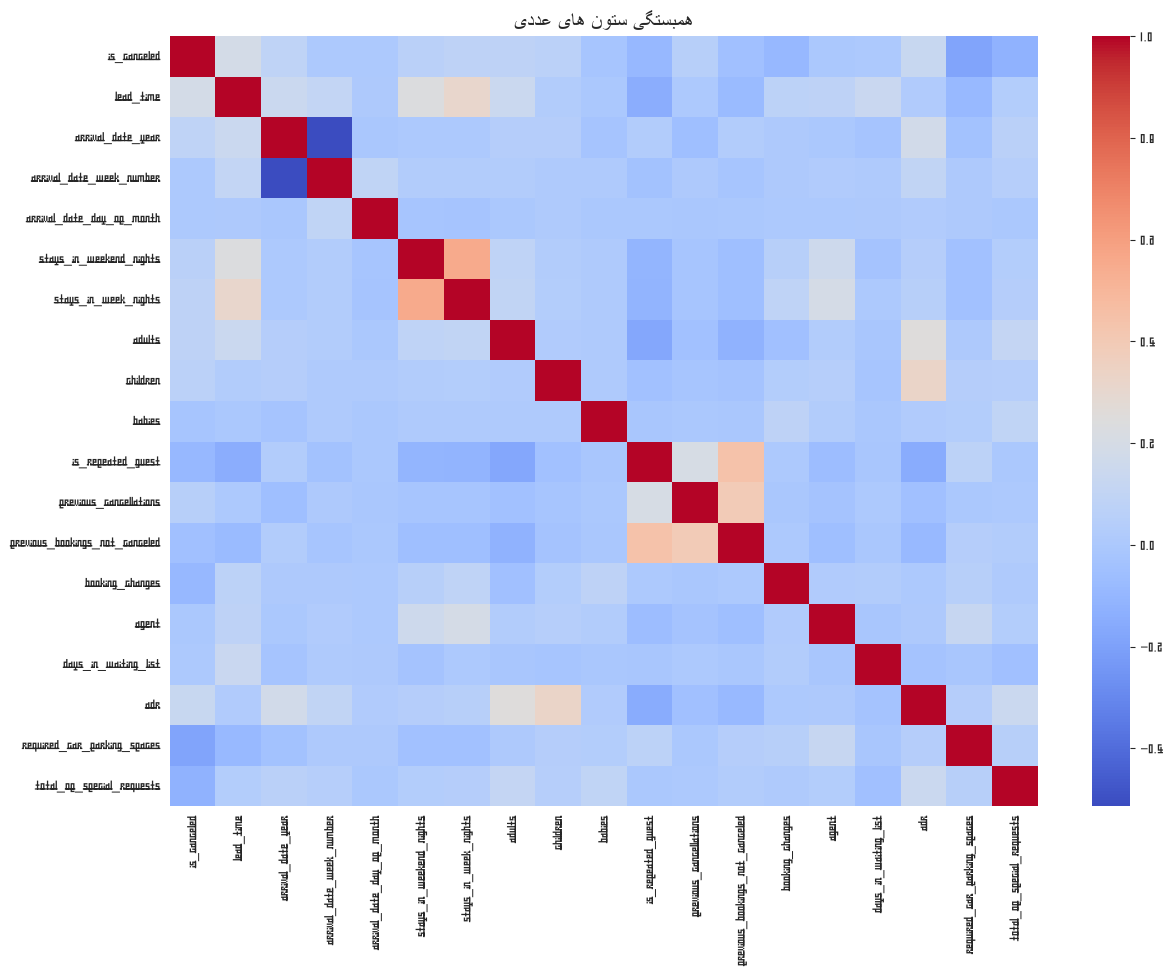

In [72]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False
)

plt.title("همبستگی ستون های عددی")

plt.savefig("images/heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

Heatmap میزان همبستگی بین ستون‌های عددی را نمایش می‌دهد

In [73]:
corr["adr"].sort_values(ascending=False)

adr                               1.000000
children                          0.326302
adults                            0.248939
arrival_date_year                 0.176063
total_of_special_requests         0.137804
is_canceled                       0.127974
arrival_date_week_number          0.098341
stays_in_week_nights              0.053285
required_car_parking_spaces       0.039111
stays_in_weekend_nights           0.038926
lead_time                         0.023533
babies                            0.023444
arrival_date_day_of_month         0.022597
agent                             0.008541
booking_changes                   0.002540
days_in_waiting_list             -0.033006
previous_cancellations           -0.050273
previous_bookings_not_canceled   -0.085730
is_repeated_guest                -0.153056
Name: adr, dtype: float64

In [74]:
df.groupby("hotel")["adr"].mean()

hotel
City Hotel      110.985270
Resort Hotel     99.030296
Name: adr, dtype: float64

In [75]:
df.groupby("customer_type")["adr"].mean()

customer_type
Contract            92.753036
Group               84.361949
Transient          110.140062
Transient-Party     87.659364
Name: adr, dtype: float64

In [76]:
df.groupby("market_segment")["adr"].mean().sort_values(ascending=False)

market_segment
Online TA        118.169814
Direct           116.579429
Aviation         100.170396
Offline TA/TO     81.764191
Groups            74.864284
Corporate         68.183234
Undefined         15.000000
Complementary      3.049245
Name: adr, dtype: float64

In [77]:
df.groupby("meal")["adr"].mean()

meal
BB           103.671603
FB           143.293667
HB           133.272635
SC            98.278183
Undefined    105.811850
Name: adr, dtype: float64

In [78]:
df.to_csv(
    "hotel_booking_clean.csv",
    index=False
)

# نتیجه گیری

در این پروژه مراحل زیر انجام شد:

- بررسی اولیه داده‌ها
- بررسی نوع داده‌ها
- بررسی داده‌های گمشده
- حذف داده‌های تکراری
- کاهش حجم حافظه
- تحلیل داده‌ها
- رسم نمودارها
- بررسی همبستگی متغیرها
- ذخیره دیتاست پاکسازی شده

## نتایج مهم

- بیشترین رزرو مربوط به City Hotel است.

- بیشترین رزرو از طریق Online TA انجام شده است.

- بیشترین مشتریان از نوع Transient هستند.

- وعده غذایی BB بیشترین فراوانی را دارد.

- درصد قابل توجهی از رزروها لغو شده‌اند.

- بیشتر مشتریان درخواست ویژه کمی ثبت کرده‌اند.

In [80]:
print("Project Finished Successfully")

Project Finished Successfully


In [81]:
print(df.shape)

(87389, 31)


In [82]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,0,No Deposit,304.0,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.0,0,1,Check-Out,2015-07-03
